
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [28]:
# ติดตั้ง Library ที่จำเป็นทั้งหมด
# รันครั้งเดียว แล้ว restart kernel

!pip install rasterio xarray rioxarray netcdf4 h5netcdf matplotlib
!pip install xee earthengine-api
!pip install dask[complete]  # สำหรับ lazy loading ข้อมูลขนาดใหญ่

In [29]:
# ตรวจสอบเวอร์ชัน
import rasterio
import xarray as xr
import rioxarray
import numpy as np
import matplotlib.pyplot as plt

print(f"Rasterio  : {rasterio.__version__}")
print(f"Xarray    : {xr.__version__}")
print(f"NumPy     : {np.__version__}")

Rasterio  : 1.5.0
Xarray    : 2026.2.0
NumPy     : 2.0.2


In [30]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# เปิดไฟล์ (ยังไม่โหลดข้อมูลเข้า memory)
src = rasterio.open('data/dem_sample.tif')

# ดู metadata ทั้งหมด
print("=" * 50)
print("📋 METADATA ของไฟล์ DEM")
print("=" * 50)
print(f"Driver     : {src.driver}")        # รูปแบบไฟล์
print(f"Width      : {src.width} pixels")   # จำนวนคอลัมน์
print(f"Height     : {src.height} pixels")  # จำนวนแถว
print(f"Count      : {src.count} band(s)")  # จำนวน band
print(f"CRS        : {src.crs}")            # ระบบพิกัด
print(f"Bounds     : {src.bounds}")          # ขอบเขต
print(f"Resolution : {src.res}")             # ความละเอียด (x, y)
print(f"Dtype      : {src.dtypes}")          # ชนิดข้อมูล
print(f"NoData     : {src.nodata}")          # ค่า NoData
print(f"Transform  :\n{src.transform}")      # Affine transform

📋 METADATA ของไฟล์ DEM
Driver     : GTiff
Width      : 200 pixels
Height     : 200 pixels
Count      : 1 band(s)
CRS        : EPSG:4326
Bounds     : BoundingBox(left=98.0, bottom=18.0, right=100.0, top=20.0)
Resolution : (0.01, 0.01)
Dtype      : ('float32',)
NoData     : -9999.0
Transform  :
| 0.01, 0.00, 98.00|
| 0.00,-0.01, 20.00|
| 0.00, 0.00, 1.00|


In [31]:
# อ่านหลาย band พร้อมกัน
with rasterio.open('data/multispectral_sample.tif') as src:
    # อ่านทุก band → (bands, rows, cols)
    all_bands = src.read()
    print(f"อ่านทุก band: {all_bands.shape}")

    # อ่านเฉพาะ band ที่ต้องการ
    red_nir = src.read([3, 4])  # เฉพาะ Red และ NIR
    print(f"อ่าน Red+NIR: {red_nir.shape}")

อ่านทุก band: (4, 200, 200)
อ่าน Red+NIR: (2, 200, 200)


In [32]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "data/dem_sample.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)


ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 200, 'height': 200, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.01, 0.0, 98.0,
       0.0, -0.01, 20.0)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


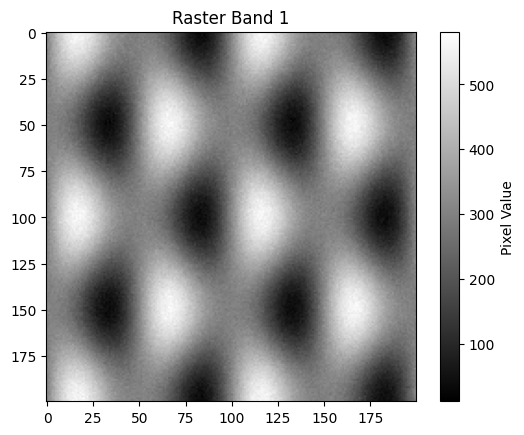

In [33]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


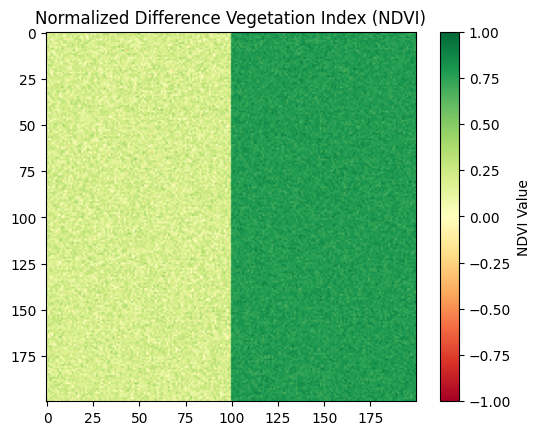

In [34]:
import numpy as np

# เปิดไฟล์ภาพดาวเทียม
# เปลี่ยนมาใช้ไฟล์ multispectral_sample.tif ที่มีหลาย band สำหรับการคำนวณ NDVI
with rasterio.open('data/multispectral_sample.tif') as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()


## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [35]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [36]:
import geopandas as gpd
from shapely.geometry import Polygon
import os

# สร้างโฟลเดอร์ data
os.makedirs('data', exist_ok=True)

# กำหนดขอบเขตของ Polygon จำลอง (ในระบบพิกัดเดียวกับ Raster: EPSG:4326)
# เลือกขอบเขตที่อยู่ใน dem_sample.tif (xmin=98.0, ymin=18.0, xmax=100.0, ymax=20.0)
polygon_coords = [
    (98.5, 18.5), # lower-left
    (99.5, 18.5), # lower-right
    (99.5, 19.5), # upper-right
    (98.5, 19.5), # upper-left
    (98.5, 18.5)  # close the polygon
]

# สร้าง Polygon object
polygon_geometry = Polygon(polygon_coords)

# สร้าง GeoDataFrame
gdf_boundary = gpd.GeoDataFrame(
    {'id': [1], 'name': ['Test_Area']},
    geometry=[polygon_geometry],
    crs="EPSG:4326"
)

# บันทึกเป็น Shapefile ในโฟลเดอร์ data
shapefile_output_path = 'data/boundary.shp'
gdf_boundary.to_file(shapefile_output_path)

print(f"✅ สร้างไฟล์ Shapefile จำลอง '{shapefile_output_path}' เรียบร้อยแล้ว")

✅ สร้างไฟล์ Shapefile จำลอง 'data/boundary.shp' เรียบร้อยแล้ว


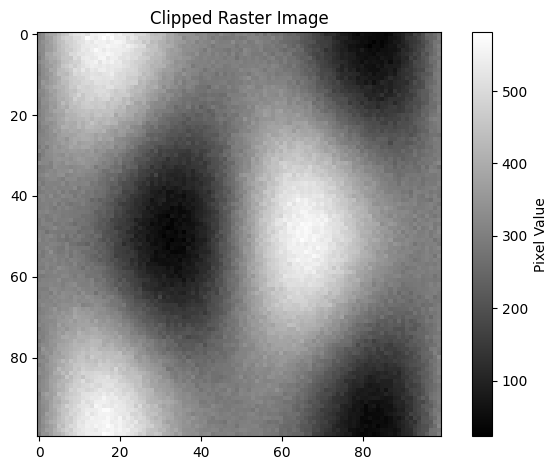

✅ ตัดภาพเรียบร้อย: 100×100 pixels
ตัดข้อมูล Raster สำเร็จ!


In [40]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "data/boundary.shp"  # แก้ไข path
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

# แสดงภาพ Raster ที่ถูกตัด
plt.imshow(out_image[0], cmap='gray') # แสดง band แรก (dem_sample.tif มี band เดียว)
plt.colorbar(label='Pixel Value')
plt.title('Clipped Raster Image')
plt.tight_layout()
plt.show()

print(f"✅ ตัดภาพเรียบร้อย: {out_image.shape[2]}×{out_image.shape[1]} pixels")
print("ตัดข้อมูล Raster สำเร็จ!")


# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


1.แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

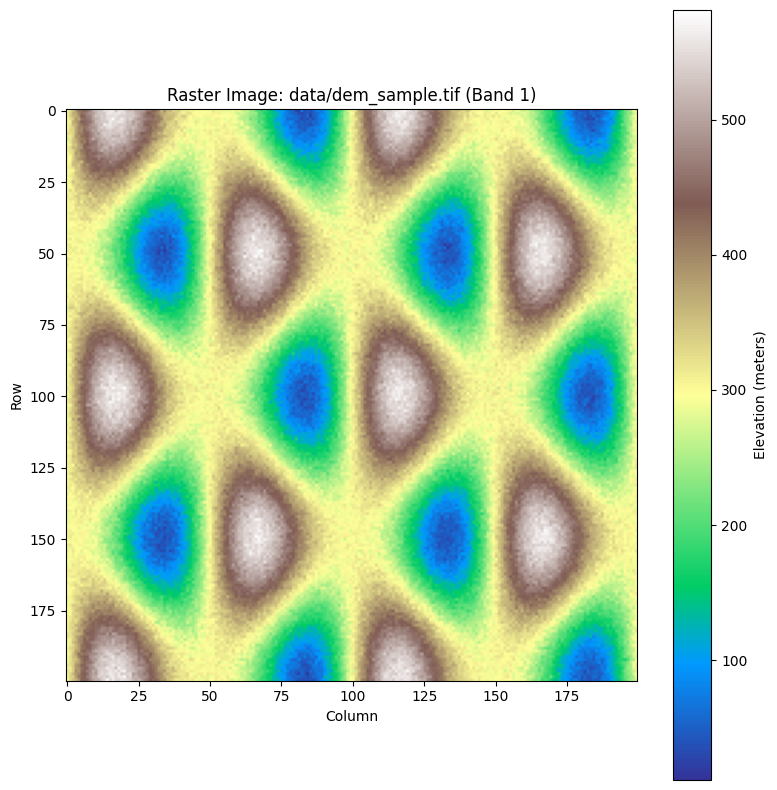

อ่านไฟล์: data/dem_sample.tif สำเร็จ
ขนาด Band 1: (200, 200)


In [41]:
import rasterio
import matplotlib.pyplot as plt

# กำหนด path ไปยังไฟล์ Raster ตัวอย่าง
raster_path = "data/dem_sample.tif"

# เปิดไฟล์ Raster
with rasterio.open(raster_path) as src:
    # อ่าน band แรกของภาพ
    band1 = src.read(1)

# แสดงภาพ Raster ด้วย Matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(band1, cmap='terrain') # ใช้ colormap 'terrain' ที่เหมาะสมกับ DEM
plt.colorbar(label='Elevation (meters)') # เพิ่มแถบสีพร้อมชื่อกำกับ
plt.title(f'Raster Image: {raster_path} (Band 1)') # ตั้งชื่อกราฟ
plt.xlabel('Column')
plt.ylabel('Row')
plt.tight_layout()
plt.show()

print(f"อ่านไฟล์: {raster_path} สำเร็จ")
print(f"ขนาด Band 1: {band1.shape}")

2.แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [42]:
import rasterio

# กำหนด path ไปยังไฟล์ Raster ตัวอย่าง
raster_path = "data/dem_sample.tif"

# เปิดไฟล์ Raster เพื่อเข้าถึงข้อมูลเมตา
with rasterio.open(raster_path) as src:
    print("=" * 50)
    print("📋 METADATA ของไฟล์ DEM")
    print("=" * 50)
    print(f"Driver     : {src.driver}")        # รูปแบบไฟล์ที่ใช้จัดเก็บข้อมูล (เช่น GeoTIFF)
    print(f"Width      : {src.width} pixels")   # จำนวนคอลัมน์ของข้อมูล Pixel
    print(f"Height     : {src.height} pixels")  # จำนวนแถวของข้อมูล Pixel
    print(f"Count      : {src.count} band(s)")  # จำนวน Band (ชั้นข้อมูล) ในไฟล์ Raster
    print(f"CRS        : {src.crs}")            # ระบบพิกัดอ้างอิง (Coordinate Reference System)
    print(f"Bounds     : {src.bounds}")          # ขอบเขตเชิงภูมิศาสตร์ของภาพ (xmin, ymin, xmax, ymax)
    print(f"Resolution : {src.res}")             # ขนาดของ Pixel ในหน่วยเชิงภูมิศาสตร์ (ความละเอียด x,y)
    print(f"Dtype      : {src.dtypes}")          # ชนิดข้อมูลของแต่ละ Pixel (เช่น float32, int16)
    print(f"NoData     : {src.nodata}")          # ค่าที่ใช้แทนข้อมูลที่ไม่มี (เช่น -9999)
    print(f"Transform  :\n{src.transform}")      # Affine transformation matrix สำหรับแปลงพิกัด Pixel <=> Geographic

print("ดึงข้อมูลเมตาสำเร็จ!")

📋 METADATA ของไฟล์ DEM
Driver     : GTiff
Width      : 200 pixels
Height     : 200 pixels
Count      : 1 band(s)
CRS        : EPSG:4326
Bounds     : BoundingBox(left=98.0, bottom=18.0, right=100.0, top=20.0)
Resolution : (0.01, 0.01)
Dtype      : ('float32',)
NoData     : -9999.0
Transform  :
| 0.01, 0.00, 98.00|
| 0.00,-0.01, 20.00|
| 0.00, 0.00, 1.00|
ดึงข้อมูลเมตาสำเร็จ!


3.แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

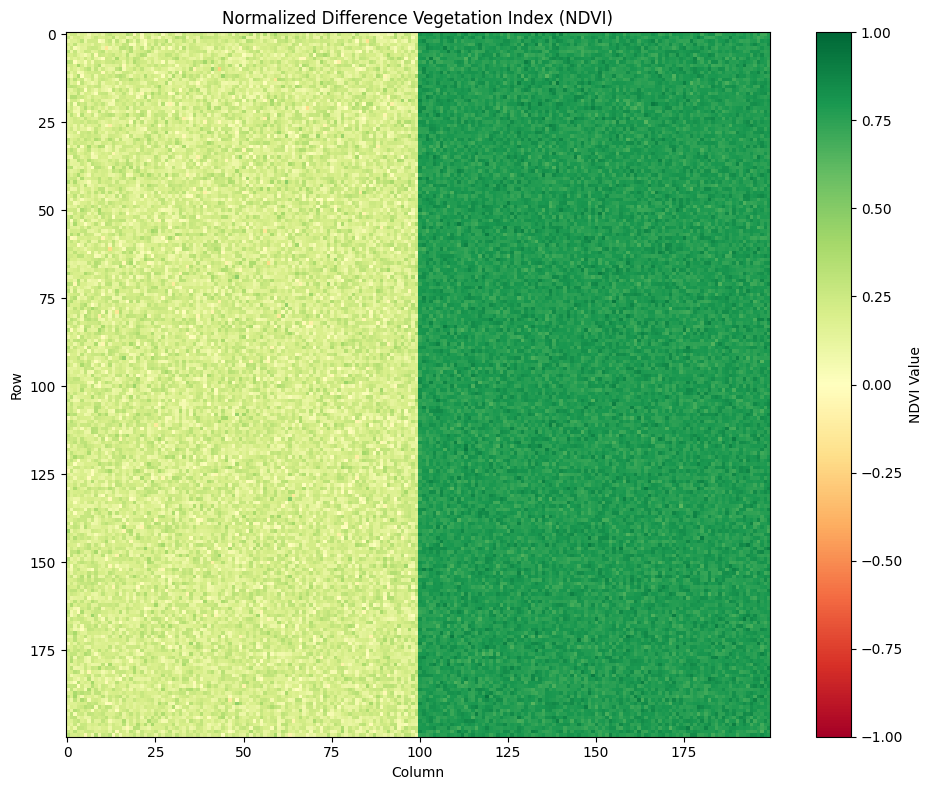

คำนวณและแสดงผล NDVI สำเร็จ!
ค่า NDVI ต่ำสุด: -0.26
ค่า NDVI สูงสุด: 0.94


In [44]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# กำหนด path ไปยังไฟล์ Raster ตัวอย่าง multispectral
multispectral_path = "data/multispectral_sample.tif"

# เปิดไฟล์ภาพดาวเทียมแบบ multispectral
with rasterio.open(multispectral_path) as dataset:
    # อ่าน band NIR (Near-Infrared) และ Red
    # สมมติว่า Band 4 คือ NIR และ Band 3 คือ Red
    # ตรวจสอบจาก metadata ของไฟล์
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

    # สำรอง metadata ของไฟล์ต้นฉบับ เพื่อใช้ในการบันทึก NDVI
    profile = dataset.profile

# คำนวณ NDVI
# สูตร: NDVI = (NIR - Red) / (NIR + Red)
# เพิ่มค่า 1e-10 เพื่อป้องกันการหารด้วยศูนย์ในกรณีที่ NIR + Red = 0
ndvi = (nir - red) / (nir + red + 1e-10)

# แสดงผล NDVI
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1) # ใช้ colormap 'RdYlGn' ที่เหมาะสมกับ NDVI
plt.colorbar(label="NDVI Value") # เพิ่มแถบสีพร้อมชื่อกำกับ
plt.title("Normalized Difference Vegetation Index (NDVI)") # ตั้งชื่อกราฟ
plt.xlabel('Column')
plt.ylabel('Row')
plt.tight_layout()
plt.show()

print("คำนวณและแสดงผล NDVI สำเร็จ!")
print(f"ค่า NDVI ต่ำสุด: {np.min(ndvi):.2f}")
print(f"ค่า NDVI สูงสุด: {np.max(ndvi):.2f}")

4.แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

✅ ตัดภาพ Raster และบันทึกเป็น 'clipped_dem_exercise.tif' เรียบร้อยแล้ว
ขนาดของภาพที่ถูกตัด: 100x100 pixels


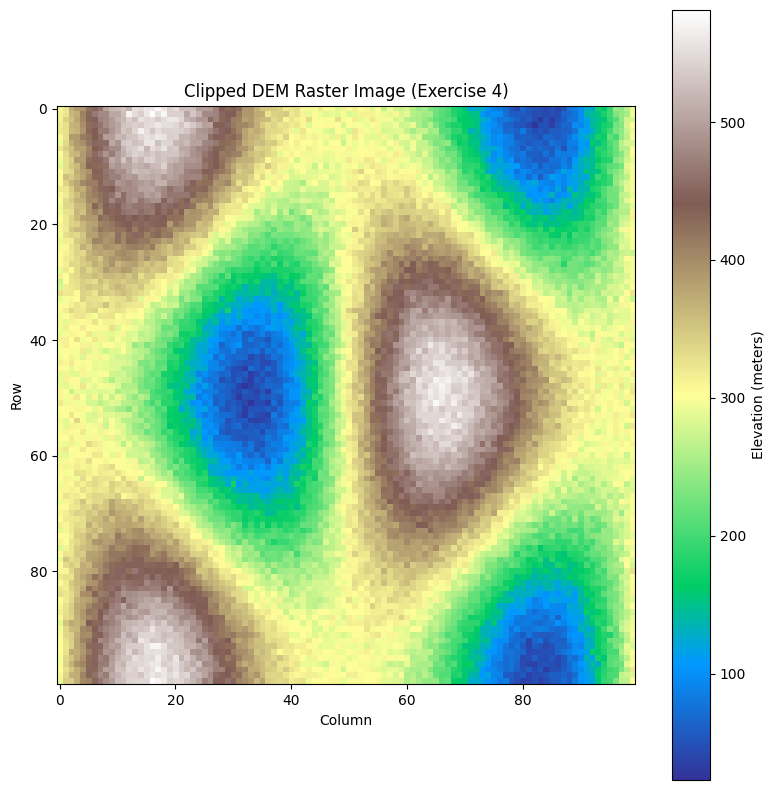

In [46]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import os

# โค้ดนี้เป็นการสร้างไฟล์ shapefile จำลอง
if not os.path.exists('data/boundary.shp'):
    os.makedirs('data', exist_ok=True)
    polygon_coords = [
        (98.5, 18.5), # lower-left
        (99.5, 18.5), # lower-right
        (99.5, 19.5), # upper-right
        (98.5, 19.5), # upper-left
        (98.5, 18.5)  # close the polygon
    ]
    from shapely.geometry import Polygon
    polygon_geometry = Polygon(polygon_coords)
    gdf_boundary = gpd.GeoDataFrame(
        {'id': [1], 'name': ['Test_Area']},
        geometry=[polygon_geometry],
        crs="EPSG:4326"
    )
    gdf_boundary.to_file('data/boundary.shp')
    print("✅ สร้างไฟล์ Shapefile จำลอง 'data/boundary.shp' เรียบร้อยแล้ว")


# กำหนด path ไปยังไฟล์ Raster ตัวอย่าง (DEM)
raster_path = "data/dem_sample.tif"

# กำหนด path ไปยังไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "data/boundary.shp"

# โหลดไฟล์ Shapefile
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon จาก GeoDataFrame เป็นรูปแบบ GeoJSON เพื่อใช้กับ rasterio.mask
geometry = [mapping(gdf.geometry[0])]

# เปิดไฟล์ Raster และทำการตัด (Clip)
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตข้อมูลเมตาของภาพ Raster ที่ถูกตัด
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": src.nodata # ตรวจสอบให้แน่ใจว่าค่า NoData ยังคงอยู่
})

# กำหนดชื่อไฟล์สำหรับบันทึกภาพ Raster ที่ถูกตัด
clipped_output_path = "clipped_dem_exercise.tif"

# บันทึกไฟล์ Raster ที่ถูกตัดเป็น GeoTIFF
with rasterio.open(clipped_output_path, "w", **out_meta) as dest:
    dest.write(out_image)

print(f"✅ ตัดภาพ Raster และบันทึกเป็น '{clipped_output_path}' เรียบร้อยแล้ว")
print(f"ขนาดของภาพที่ถูกตัด: {out_image.shape[2]}x{out_image.shape[1]} pixels")

# แสดงภาพ Raster ที่ถูกตัดด้วย Matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(out_image[0], cmap='terrain')
plt.colorbar(label='Elevation (meters)')
plt.title('Clipped DEM Raster Image (Exercise 4)')
plt.xlabel('Column')
plt.ylabel('Row')
plt.tight_layout()
plt.show()
